In [40]:
from pathlib import Path
import random

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

SEED = 42


def set_global_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


set_global_seed(SEED)

X_cols = [
    "Construction period",
    "Typology",
    "Primary Code",
    "Hybrid Structure",
    "Location_code",
]

y_cols = ["Concrete", "Glass", "Steel", "Wood", "Brick"]

In [41]:
class JointMDN(nn.Module):
    def __init__(self, input_dim: int = 5, M: int = 5, K: int = 3):
        super().__init__()
        self.input_dim = input_dim
        self.M = M
        self.K = K
        self.num_cholesky_params = M * (M + 1) // 2

        output_dim = K + (K * M) + (K * self.num_cholesky_params)
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
        )

    def build_cholesky(self, L_params: torch.Tensor) -> torch.Tensor:
        batch_size = L_params.shape[0]
        L = L_params.new_zeros(batch_size, self.K, self.M, self.M)

        tril_rows, tril_cols = torch.tril_indices(
            row=self.M, col=self.M, offset=0, device=L_params.device
        )
        L[:, :, tril_rows, tril_cols] = L_params

        diag_idx = torch.arange(self.M, device=L_params.device)
        L[:, :, diag_idx, diag_idx] = (
            F.softplus(L[:, :, diag_idx, diag_idx]) + 1e-6
        )
        return L

    def forward(self, x: torch.Tensor):
        output = self.network(x)

        pi_end = self.K
        mu_end = pi_end + (self.K * self.M)

        pi_logits = output[:, :pi_end]
        mu = output[:, pi_end:mu_end].view(-1, self.K, self.M)
        L_params = output[:, mu_end:].view(-1, self.K, self.num_cholesky_params)
        L = self.build_cholesky(L_params)

        return pi_logits, mu, L

In [42]:
def mdn_loss(pi_logits: torch.Tensor, mu: torch.Tensor, L: torch.Tensor, y_true: torch.Tensor):
    component_distribution = torch.distributions.MultivariateNormal(
        loc=mu, scale_tril=L
    )
    mixture_distribution = torch.distributions.Categorical(logits=pi_logits)
    joint_distribution = torch.distributions.MixtureSameFamily(
        mixture_distribution, component_distribution
    )

    log_prob = joint_distribution.log_prob(y_true)
    return -log_prob.mean()

In [43]:
def prepare_dataloaders(
    file_path: str | Path = "Integrated_MI_database.xlsx",
    batch_size: int = 64,
    random_state: int = SEED,
    clip_upper_quantile: float | None = 0.99,
    clip_materials: tuple[str, ...] = ("Steel", "Glass"),
):
    file_path = Path(file_path)
    if not file_path.is_absolute():
        file_path = Path.cwd() / file_path

    df = pd.read_excel(file_path)

    df["Construction period"] = pd.to_numeric(
        df["Construction period"], errors="coerce"
    )
    df = df.dropna(subset=X_cols + y_cols).reset_index(drop=True)

    X = df[X_cols].copy()
    y_raw = df[y_cols].to_numpy(dtype=np.float32)

    X_train, X_temp, y_train_raw, y_temp_raw = train_test_split(
        X, y_raw, test_size=0.30, random_state=random_state
    )
    X_val, X_test, y_val_raw, y_test_raw = train_test_split(
        X_temp, y_temp_raw, test_size=0.50, random_state=random_state
    )

    clip_bounds = None
    if clip_upper_quantile is not None:
        if not (0.0 <= clip_upper_quantile <= 1.0):
            raise ValueError("clip_upper_quantile must satisfy 0 <= q <= 1")

        material_to_idx = {material: idx for idx, material in enumerate(y_cols)}
        selected_materials = [
            material for material in clip_materials if material in material_to_idx
        ]

        upper_bounds = {}
        for material in selected_materials:
            idx = material_to_idx[material]
            upper_bound = np.quantile(y_train_raw[:, idx], clip_upper_quantile)
            y_train_raw[:, idx] = np.minimum(y_train_raw[:, idx], upper_bound)
            y_val_raw[:, idx] = np.minimum(y_val_raw[:, idx], upper_bound)
            y_test_raw[:, idx] = np.minimum(y_test_raw[:, idx], upper_bound)
            upper_bounds[material] = float(upper_bound)

        clip_bounds = {
            "upper_quantile": clip_upper_quantile,
            "upper_bounds": upper_bounds,
        }

    y_train = np.log1p(y_train_raw)
    y_val = np.log1p(y_val_raw)
    y_test = np.log1p(y_test_raw)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), ["Construction period"]),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                ["Typology", "Primary Code", "Hybrid Structure", "Location_code"],
            ),
        ]
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_val)
    X_test_processed = preprocessor.transform(X_test)

    X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_generator = torch.Generator().manual_seed(random_state)
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, generator=train_generator
    )
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return {
        "X_train": X_train_tensor,
        "X_val": X_val_tensor,
        "X_test": X_test_tensor,
        "y_train": y_train_tensor,
        "y_val": y_val_tensor,
        "y_test": y_test_tensor,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "preprocessor": preprocessor,
        "clip_bounds": clip_bounds,
    }

In [44]:
data = prepare_dataloaders()
print("Data preparation complete.")
print(f"X_train shape: {data['X_train'].shape}, y_train shape: {data['y_train'].shape}")
print(f"X_val shape:   {data['X_val'].shape}, y_val shape:   {data['y_val'].shape}")
print(f"X_test shape:  {data['X_test'].shape}, y_test shape:  {data['y_test'].shape}")

Data preparation complete.
X_train shape: torch.Size([632, 22]), y_train shape: torch.Size([632, 5])
X_val shape:   torch.Size([135, 22]), y_val shape:   torch.Size([135, 5])
X_test shape:  torch.Size([136, 22]), y_test shape:  torch.Size([136, 5])


In [45]:
# Optuna-based hyperparameter tuning for JointMDN
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        pi_logits, mu, L = model(X_batch)
        loss = mdn_loss(pi_logits, mu, L, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def evaluate_loss(model, loader, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            pi_logits, mu, L = model(X_batch)
            loss = mdn_loss(pi_logits, mu, L, y_batch)
            running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def objective(trial):
    K = trial.suggest_int("K", 3, 7)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    trial_seed = SEED + trial.number
    set_global_seed(trial_seed)

    tuned_data = prepare_dataloaders(batch_size=batch_size, random_state=trial_seed)
    X_train = tuned_data["X_train"].to(DEVICE)
    input_dim = X_train.shape[1]

    model = JointMDN(input_dim=input_dim, M=5, K=K).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_loader = tuned_data["train_loader"]
    val_loader = tuned_data["val_loader"]

    epochs = 60
    best_val_loss = float("inf")

    for epoch in range(epochs):
        _ = train_one_epoch(model, train_loader, optimizer, DEVICE)
        val_loss = evaluate_loss(model, val_loader, DEVICE)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_loss


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
)
study.optimize(objective, n_trials=30)

print("Best trial:")
print(f"  Value (best val loss): {study.best_value:.4f}")
print(f"  Params: {study.best_params}")

best_params = study.best_params

# Rebuild data and train final model with best hyperparameters.
set_global_seed(SEED)
data = prepare_dataloaders(batch_size=best_params["batch_size"], random_state=SEED)
input_dim = data["X_train"].shape[1]
model = JointMDN(input_dim=input_dim, M=5, K=best_params["K"]).to(DEVICE)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"],
)

train_loader = data["train_loader"]
val_loader = data["val_loader"]
epochs = 100

best_state_dict = None
best_val_loss = float("inf")

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss = evaluate_loss(model, val_loader, DEVICE)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = {
            key: value.detach().cpu().clone() for key, value in model.state_dict().items()
        }

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d}/{epochs} - "
            f"Training Loss: {train_loss:.4f} - Validation Loss: {val_loss:.4f}"
        )

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

model = model.to("cpu")
print(f"Final best validation loss: {best_val_loss:.4f}")

[I 2026-04-20 16:16:17,585] A new study created in memory with name: no-name-23914476-b0d9-4d99-8a93-e55f2c69963a
[I 2026-04-20 16:16:20,165] Trial 0 finished with value: 4.460950786096078 and parameters: {'K': 4, 'lr': 0.004123206532618728, 'weight_decay': 4.570563099801451e-05, 'batch_size': 32}. Best is trial 0 with value: 4.460950786096078.
[I 2026-04-20 16:16:21,030] Trial 1 finished with value: 3.6090153340940123 and parameters: {'K': 3, 'lr': 0.0029621516588303515, 'weight_decay': 1.0129197956845722e-05, 'batch_size': 128}. Best is trial 1 with value: 3.6090153340940123.
[I 2026-04-20 16:16:22,045] Trial 2 finished with value: 6.890267216717755 and parameters: {'K': 7, 'lr': 0.00022948683681130568, 'weight_decay': 8.111941985431907e-08, 'batch_size': 128}. Best is trial 1 with value: 3.6090153340940123.
[I 2026-04-20 16:16:22,934] Trial 3 finished with value: 6.480655945671929 and parameters: {'K': 5, 'lr': 0.0003124565071260876, 'weight_decay': 1.1462107403425014e-05, 'batch_si

Best trial:
  Value (best val loss): 3.4381
  Params: {'K': 4, 'lr': 0.0016275699639592654, 'weight_decay': 1.0755582445392765e-08, 'batch_size': 32}
Epoch 010/100 - Training Loss: 5.2802 - Validation Loss: 5.6674
Epoch 020/100 - Training Loss: 3.5167 - Validation Loss: 4.4111
Epoch 030/100 - Training Loss: 3.3356 - Validation Loss: 4.4940
Epoch 040/100 - Training Loss: 3.1609 - Validation Loss: 4.1053
Epoch 050/100 - Training Loss: 3.0627 - Validation Loss: 3.9719
Epoch 060/100 - Training Loss: 2.8399 - Validation Loss: 4.0725
Epoch 070/100 - Training Loss: 2.9488 - Validation Loss: 4.0738
Epoch 080/100 - Training Loss: 2.8792 - Validation Loss: 4.3228
Epoch 090/100 - Training Loss: 2.5563 - Validation Loss: 4.5068
Epoch 100/100 - Training Loss: 2.5646 - Validation Loss: 4.2325
Final best validation loss: 3.7904


In [46]:
def predict_material_ranges(model, X_new_tensor, num_samples=1000, sample_seed=SEED):
    model.eval()

    if sample_seed is not None:
        torch.manual_seed(sample_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(sample_seed)
            torch.cuda.manual_seed_all(sample_seed)

    with torch.no_grad():
        pi_logits, mu, L = model(X_new_tensor)

        component_distribution = torch.distributions.MultivariateNormal(
            loc=mu, scale_tril=L
        )
        mixture_distribution = torch.distributions.Categorical(logits=pi_logits)
        joint_distribution = torch.distributions.MixtureSameFamily(
            mixture_distribution, component_distribution
        )

        samples = joint_distribution.sample((num_samples,))
        percentiles = torch.quantile(
            samples, q=torch.tensor([0.05, 0.50, 0.95], device=samples.device), dim=0
        )

    percentiles_np = np.expm1(percentiles.cpu().numpy())

    result = {}
    for i, material in enumerate(y_cols):
        result[material] = {
            "p5": percentiles_np[0, :, i],
            "p50": percentiles_np[1, :, i],
            "p95": percentiles_np[2, :, i],
        }

    return result

In [47]:
def evaluate_mdn(model, X_test_tensor, y_test_df, num_samples=1000):
    prediction_ranges = predict_material_ranges(
        model, X_test_tensor, num_samples=num_samples
    )

    alpha = 0.10  # 90% prediction interval
    material_means = y_test_df.mean()

    for material in y_cols:
        y_true = y_test_df[material].to_numpy()
        y_pred_median = prediction_ranges[material]["p50"]
        lower_bound = prediction_ranges[material]["p5"]
        upper_bound = prediction_ranges[material]["p95"]

        mae = np.mean(np.abs(y_pred_median - y_true))
        coverage = np.mean((y_true > lower_bound) & (y_true < upper_bound)) * 100
        mpiw = np.mean(upper_bound - lower_bound)

        material_mean = material_means[material]
        nmpiw = mpiw / material_mean if material_mean != 0 else np.nan

        interval_width = upper_bound - lower_bound
        winkler = np.where(
            y_true < lower_bound,
            interval_width + (2.0 / alpha) * (lower_bound - y_true),
            np.where(
                y_true > upper_bound,
                interval_width + (2.0 / alpha) * (y_true - upper_bound),
                interval_width,
            ),
        )
        winkler_score = np.mean(winkler)

        print(
            f"{material}: MAE = {mae:.4f}, 90% Coverage = {coverage:.2f}%, "
            f"MPIW = {mpiw:.4f}, MPIW/Mean = {nmpiw:.4f}, "
            f"Winkler Score = {winkler_score:.4f}"
        )

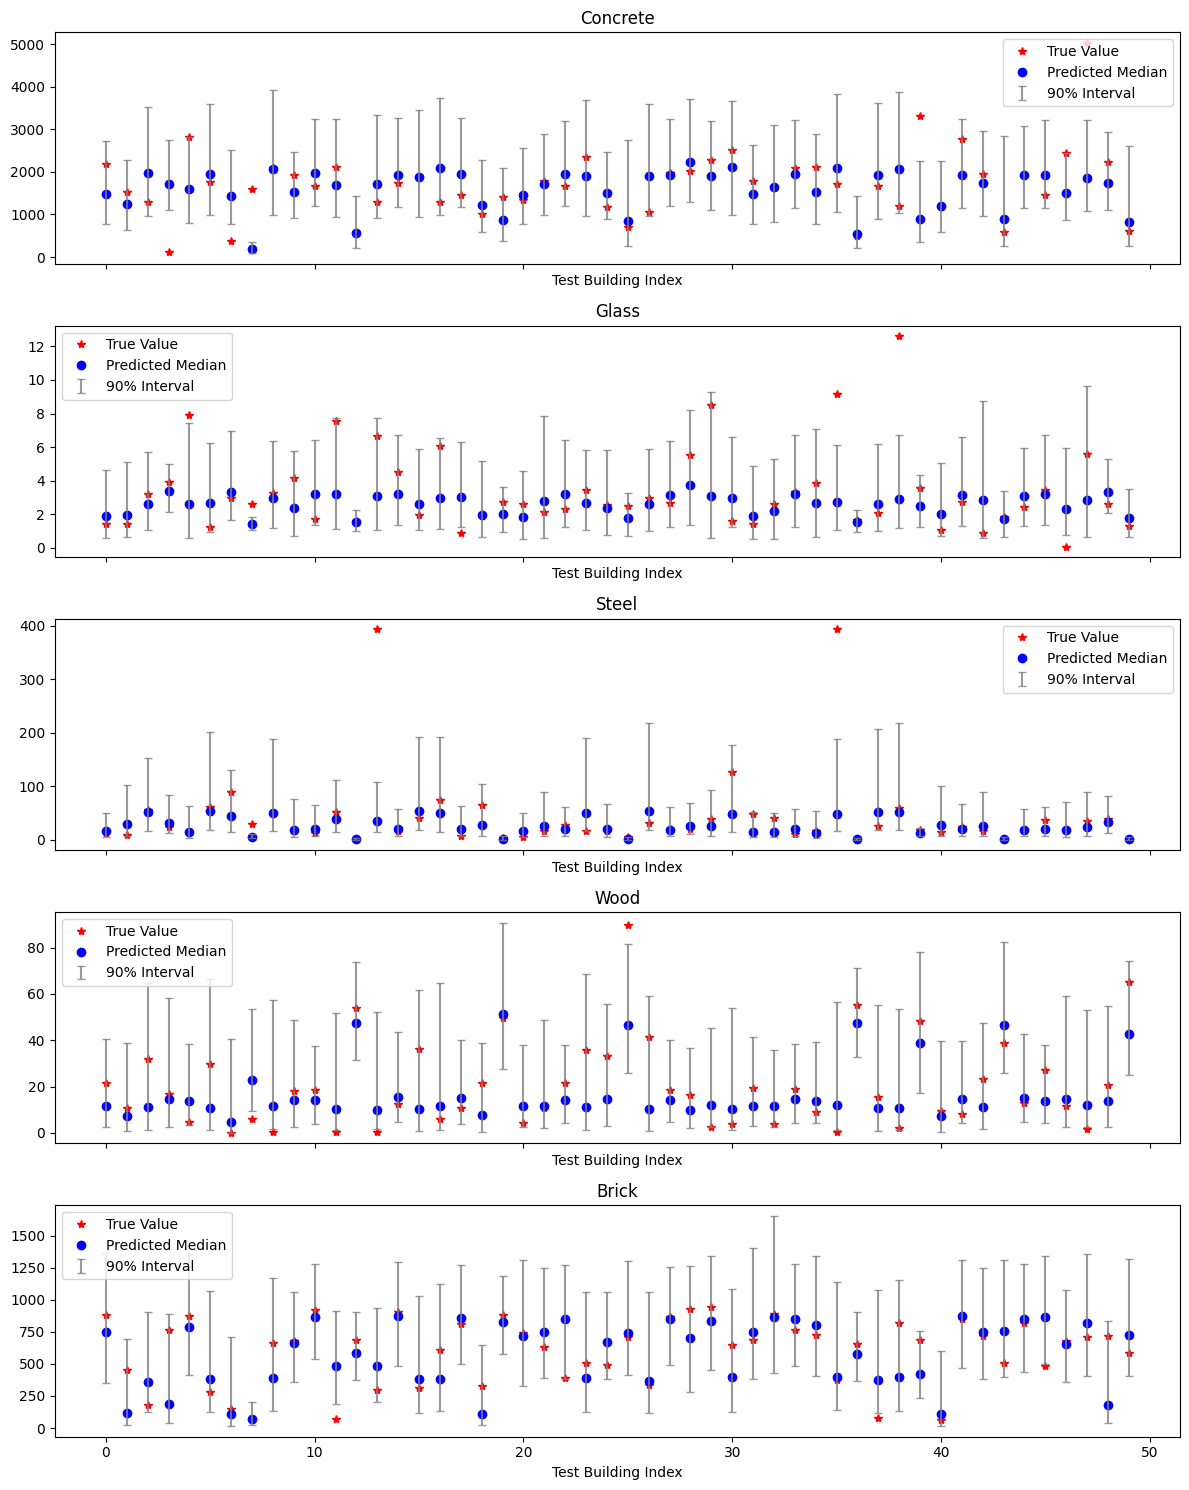

In [48]:
import matplotlib.pyplot as plt

# Build y_test_df in original kg/m² units from the stored test tensor
# (the tensors in `data` are log-transformed, so we back-transform here)
y_test_df = pd.DataFrame(
    np.expm1(data["y_test"].cpu().numpy()), columns=y_cols
)

# Predict ranges for the first 50 buildings in the test set
X_test_first50 = data["X_test"][:50]
pred_ranges = predict_material_ranges(model, X_test_first50, num_samples=1000)

fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
x_idx = np.arange(50)

for i, material in enumerate(y_cols):
    ax = axes[i]
    y_true = y_test_df[material].iloc[:50].to_numpy()
    y_med = pred_ranges[material]["p50"]
    y_low = pred_ranges[material]["p5"]
    y_high = pred_ranges[material]["p95"]

    ax.plot(x_idx, y_true, "r*", label="True Value")
    ax.plot(x_idx, y_med, "bo", label="Predicted Median")
    ax.errorbar(
        x_idx,
        y_med,
        yerr=[y_med - y_low, y_high - y_med],
        fmt="none",
        ecolor="gray",
        alpha=0.8,
        capsize=3,
        label="90% Interval",
    )

    ax.set_title(material)
    ax.set_xlabel("Test Building Index")
    ax.legend()

plt.tight_layout()
plt.show()

In [49]:
# Print model performance on the full test set
evaluate_mdn(model, data["X_test"], y_test_df, num_samples=1000)

Concrete: MAE = 463.6529, 90% Coverage = 91.91%, MPIW = 2120.8506, MPIW/Mean = 1.2930, Winkler Score = 3294.3167
Glass: MAE = 1.4608, 90% Coverage = 89.71%, MPIW = 5.3638, MPIW/Mean = 1.6630, Winkler Score = 8.9254
Steel: MAE = 23.4928, 90% Coverage = 90.44%, MPIW = 80.6657, MPIW/Mean = 1.9205, Winkler Score = 254.4081
Wood: MAE = 9.5663, 90% Coverage = 87.50%, MPIW = 47.1522, MPIW/Mean = 2.4007, Winkler Score = 55.9109
Brick: MAE = 153.1880, 90% Coverage = 92.65%, MPIW = 823.5353, MPIW/Mean = 1.3579, Winkler Score = 966.4341


In [50]:
import joblib
import json

joblib.dump(data["preprocessor"], "preprocessor.joblib")
torch.save(model.state_dict(), "mdn_model_weights.pth")

with open("best_mdn_hparams.json", "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2)

print("Saved preprocessor.joblib, mdn_model_weights.pth, and best_mdn_hparams.json")

Saved preprocessor.joblib, mdn_model_weights.pth, and best_mdn_hparams.json
